# 1. Inspeção dos Dados

Base utilizada: **Breast Cancer Wisconsin (Diagnostic)**, com exames classificados como tumor maligno (`M`) ou benigno (`B`).
Fonte: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Esta etapa caracteriza a estrutura da base e identifica problemas de qualidade dos dados. Os dados não são modificados; os tratamentos necessários são listados ao final e aplicados na etapa de limpeza (`02_data_cleaning.ipynb`).

## 1.1 Importação das bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 1.2 Carregamento da base

In [2]:
DATA_PATH = "../data/raw/breast_cancer_wisconsin.csv"

df = pd.read_csv(DATA_PATH)

## 1.3 Visualização inicial dos dados

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


Cada registro corresponde a um exame. Além de `id` e `diagnosis`, as colunas descrevem os núcleos celulares observados em imagens digitalizadas de punção aspirativa por agulha fina (PAAF). São 10 características (raio, textura, perímetro, área, suavidade, compacidade, concavidade, pontos côncavos, simetria e dimensão fractal), cada uma medida de três formas:

- `_mean`: média;
- `_se`: erro padrão;
- `_worst`: média dos três maiores valores.

## 1.4 Dimensões do dataset

In [5]:
n_rows, n_cols = df.shape
print(f"Linhas: {n_rows}")
print(f"Colunas: {n_cols}")

Linhas: 569
Colunas: 33


In [6]:
df.columns.tolist()

['id',
 'diagnosis',
 'radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave points_worst',
 'symmetry_worst',
 'fractal_dimension_worst',
 'Unnamed: 32']

A base possui 569 registros e 33 colunas.

## 1.5 Informações gerais e tipos das variáveis

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [8]:
df.dtypes.value_counts()

float64    31
int64       1
str         1
Name: count, dtype: int64

In [9]:
[col for col in df.columns if " " in col or col.startswith("Unnamed")]

['concave points_mean',
 'concave points_se',
 'concave points_worst',
 'Unnamed: 32']

As 30 variáveis de medida foram lidas como `float64` e `diagnosis` é a única coluna textual. Há uma coluna não prevista, `Unnamed: 32`, gerada pela vírgula ao final do cabeçalho do CSV. As colunas `concave points_*` contêm espaço no nome.

## 1.6 Estatísticas descritivas

In [10]:
df.drop(columns=["id"]).describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


In [11]:
features = df.select_dtypes("number").drop(columns=["id"]).dropna(axis=1, how="all")

value_range = pd.DataFrame({"min": features.min(), "max": features.max()})
value_range["amplitude"] = value_range["max"] - value_range["min"]
value_range.sort_values("amplitude", ascending=False)

,min,max,amplitude
area_worst,185.200000,4254.00000,4068.800000
area_mean,143.500000,2501.00000,2357.500000
area_se,6.802000,542.20000,535.398000
perimeter_worst,50.410000,251.20000,200.790000
perimeter_mean,43.790000,188.50000,144.710000
texture_worst,12.020000,49.54000,37.520000
texture_mean,9.710000,39.28000,29.570000
radius_worst,7.930000,36.04000,28.110000
perimeter_se,0.757000,21.98000,21.223000
radius_mean,6.981000,28.11000,21.129000


In [12]:
(features == 0).sum().loc[lambda s: s > 0]

concavity_mean          13
concave points_mean     13
concavity_se            13
concave points_se       13
concavity_worst         13
concave points_worst    13
dtype: int64

As variáveis apresentam escalas muito diferentes: as medidas de área chegam a 4.254, enquanto suavidade e dimensão fractal ficam abaixo de 1. Modelos sensíveis à escala, como KNN e regressão logística, exigirão padronização.

Há 13 exames com valor `0` nas seis colunas de concavidade e pontos côncavos. Como a ausência de concavidade é fisicamente possível, esses valores são considerados válidos, e não dados ausentes.

## 1.7 Verificação de valores ausentes

In [13]:
missing = pd.DataFrame({
    "ausentes": df.isnull().sum(),
    "percentual": (df.isnull().mean() * 100).round(2),
})
missing[missing["ausentes"] > 0]

,ausentes,percentual
Unnamed: 32,569,100.0


In [14]:
print(f"Total de valores ausentes: {df.isnull().sum().sum()}")
print(f"Total sem a coluna 'Unnamed: 32': {df.drop(columns=['Unnamed: 32'], errors='ignore').isnull().sum().sum()}")

Total de valores ausentes: 569
Total sem a coluna 'Unnamed: 32': 0


A única coluna com valores ausentes é `Unnamed: 32`, vazia em todos os 569 registros. As demais colunas estão completas.

## 1.8 Verificação de registros duplicados

In [15]:
print(f"Linhas duplicadas: {df.duplicated().sum()}")
print(f"IDs duplicados: {df['id'].duplicated().sum()}")
print(f"Linhas duplicadas desconsiderando o id: {df.drop(columns=['id']).duplicated().sum()}")

Linhas duplicadas: 0
IDs duplicados: 0
Linhas duplicadas desconsiderando o id: 0


Não há registros duplicados, nem considerando o `id` nem desconsiderando-o, e cada `id` aparece uma única vez.

## 1.9 Distribuição inicial da variável diagnosis

In [16]:
diagnosis_counts = pd.DataFrame({
    "quantidade": df["diagnosis"].value_counts(),
    "percentual": (df["diagnosis"].value_counts(normalize=True) * 100).round(2),
})
diagnosis_counts

,quantidade,percentual
diagnosis,,
B,357,62.74
M,212,37.26


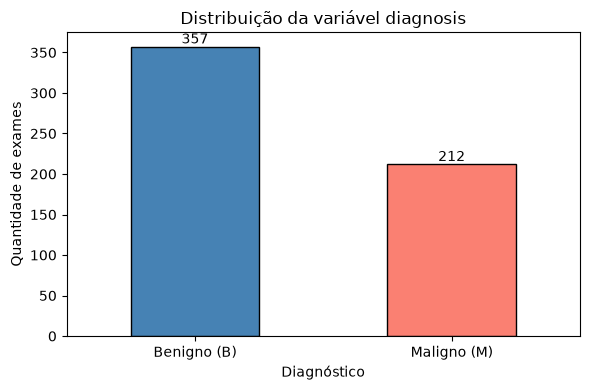

In [17]:
ax = df["diagnosis"].value_counts().rename({"B": "Benigno (B)", "M": "Maligno (M)"}).plot(
    kind="bar", color=["steelblue", "salmon"], edgecolor="black", figsize=(6, 4)
)
ax.set_title("Distribuição da variável diagnosis")
ax.set_xlabel("Diagnóstico")
ax.set_ylabel("Quantidade de exames")
ax.tick_params(axis="x", rotation=0)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

A base tem 357 casos benignos (62,7%) e 212 malignos (37,3%). O desbalanceamento é moderado e não impede a modelagem, mas indica o uso de separação estratificada entre treino, validação e teste. Como um falso negativo (tumor maligno classificado como benigno) é o erro mais grave neste problema, o **recall** da classe maligna deve receber atenção especial na avaliação.

## 1.10 Conclusões da inspeção

A base contém 569 exames e 33 colunas: `id`, `diagnosis`, 30 variáveis numéricas de medida e uma coluna vazia (`Unnamed: 32`). Não há valores ausentes nas variáveis de medida nem registros duplicados. A variável alvo está distribuída em 357 casos benignos (62,7%) e 212 malignos (37,3%).

**Tratamentos indicados para a limpeza**

| Item | Situação encontrada | Tratamento |
|---|---|---|
| `Unnamed: 32` | 100% vazia, gerada pela vírgula ao final do cabeçalho | Remover |
| `id` | Identificador único, sem valor preditivo | Remover |
| `diagnosis` | Categórica (`M`/`B`) | Converter para `1`/`0` |
| Valores ausentes | Nenhum nas variáveis de medida | Nenhum |
| Duplicatas | Nenhuma | Nenhum |
| Zeros em concavidade | 13 exames, valores plausíveis | Manter |
| `concave points_*` | Espaço no nome da coluna | Renomear (opcional) |

**Implicações para as etapas seguintes**

- As diferenças de escala entre as variáveis exigem padronização no pipeline de pré-processamento.
- O desbalanceamento moderado entre as classes indica separação estratificada e avaliação por recall e F1-score, além da acurácia.